In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("../data/StudentsPerformance.csv")

df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [4]:
df.shape


(1000, 8)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race/ethnicity               1000 non-null   str  
 2   parental level of education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test preparation course      1000 non-null   str  
 5   math score                   1000 non-null   int64
 6   reading score                1000 non-null   int64
 7   writing score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


In [6]:
df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [9]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

categorical_cols = df.select_dtypes(
    exclude=np.number
).columns.tolist()

print("Числовые признаки:")
print(numeric_cols)

print("\nКатегориальные признаки:")
print(categorical_cols)

Числовые признаки:
['math score', 'reading score', 'writing score']

Категориальные признаки:
['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']


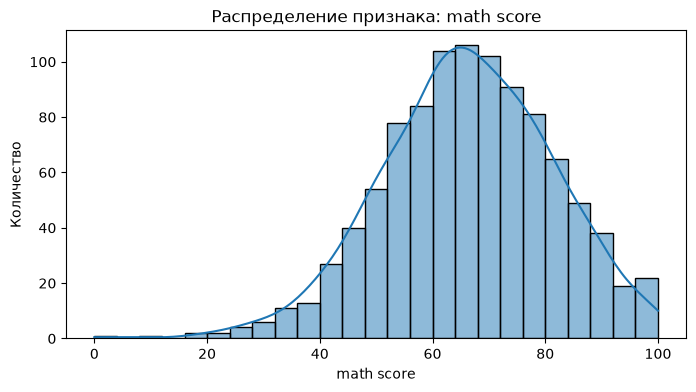

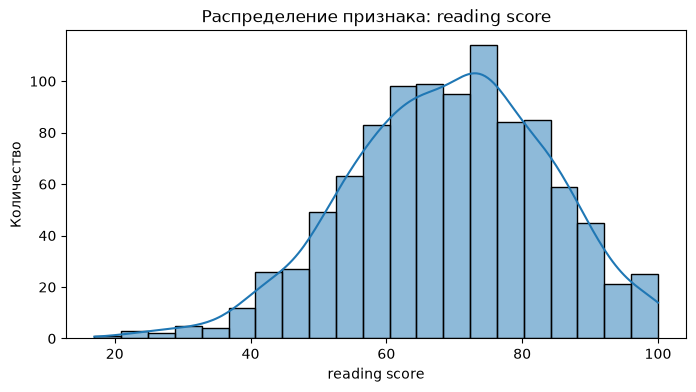

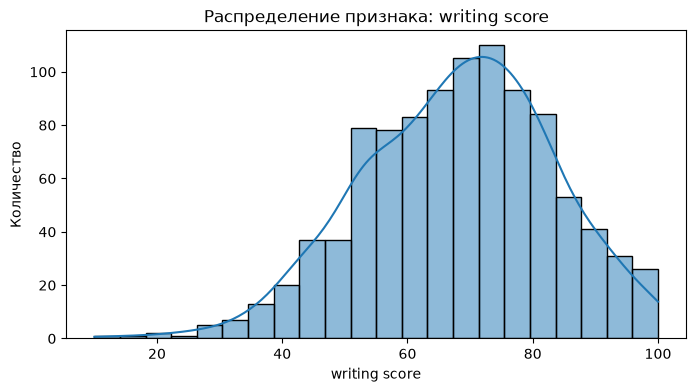

In [10]:
for col in numeric_cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[col].dropna(), kde=True)
    plt.title(f"Распределение признака: {col}")
    plt.xlabel(col)
    plt.ylabel("Количество")
    plt.show()

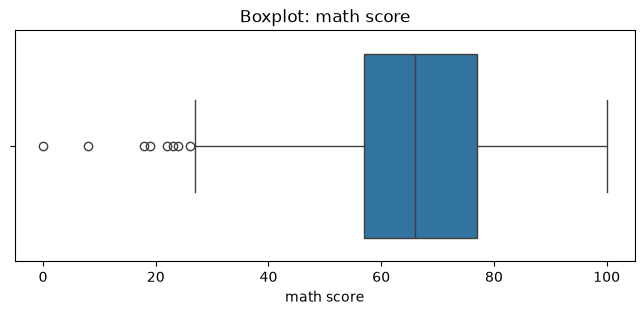

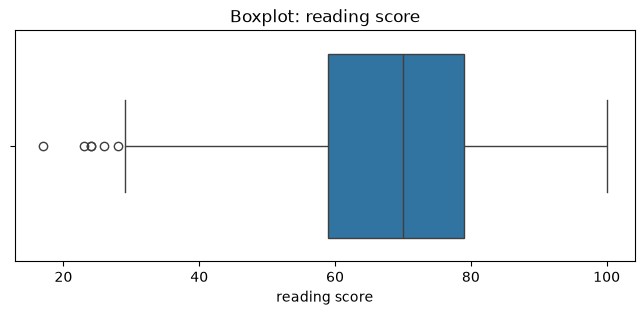

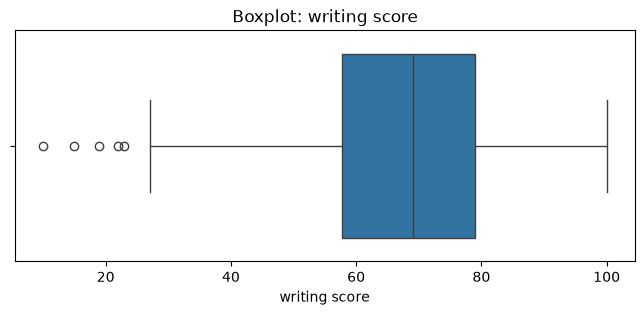

In [11]:
for col in numeric_cols:
    plt.figure(figsize=(8, 3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot: {col}")
    plt.show()

In [12]:
outliers = {}

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    count = ((df[col] < lower) | (df[col] > upper)).sum()
    
    outliers[col] = count

outliers_df = pd.DataFrame.from_dict(
    outliers,
    orient="index",
    columns=["Количество выбросов"]
)

outliers_df

,Количество выбросов
math score,8
reading score,6
writing score,5


In [13]:
for col in categorical_cols:
    print(f"\n===== {col} =====")
    print(df[col].value_counts())


===== gender =====
gender
female    518
male      482
Name: count, dtype: int64

===== race/ethnicity =====
race/ethnicity
group C    319
group D    262
group B    190
group E    140
group A     89
Name: count, dtype: int64

===== parental level of education =====
parental level of education
some college          226
associate's degree    222
high school           196
some high school      179
bachelor's degree     118
master's degree        59
Name: count, dtype: int64

===== lunch =====
lunch
standard        645
free/reduced    355
Name: count, dtype: int64

===== test preparation course =====
test preparation course
none         642
completed    358
Name: count, dtype: int64


In [14]:
for col in categorical_cols:
    print(f"\n===== {col} =====")
    print(
        (df[col].value_counts(normalize=True) * 100).round(2)
    )


===== gender =====
gender
female    51.8
male      48.2
Name: proportion, dtype: float64

===== race/ethnicity =====
race/ethnicity
group C    31.9
group D    26.2
group B    19.0
group E    14.0
group A     8.9
Name: proportion, dtype: float64

===== parental level of education =====
parental level of education
some college          22.6
associate's degree    22.2
high school           19.6
some high school      17.9
bachelor's degree     11.8
master's degree        5.9
Name: proportion, dtype: float64

===== lunch =====
lunch
standard        64.5
free/reduced    35.5
Name: proportion, dtype: float64

===== test preparation course =====
test preparation course
none         64.2
completed    35.8
Name: proportion, dtype: float64


In [15]:
for col in categorical_cols:
    frequencies = df[col].value_counts(normalize=True) * 100
    
    print(f"\n===== {col} =====")
    print(frequencies[frequencies < 1])


===== gender =====
Series([], Name: proportion, dtype: float64)

===== race/ethnicity =====
Series([], Name: proportion, dtype: float64)

===== parental level of education =====
Series([], Name: proportion, dtype: float64)

===== lunch =====
Series([], Name: proportion, dtype: float64)

===== test preparation course =====
Series([], Name: proportion, dtype: float64)


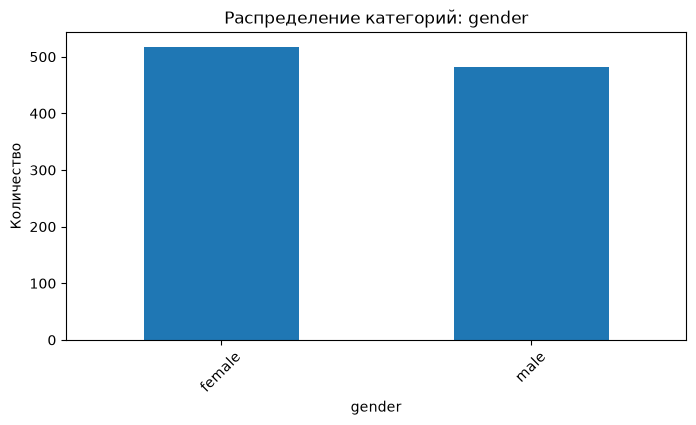

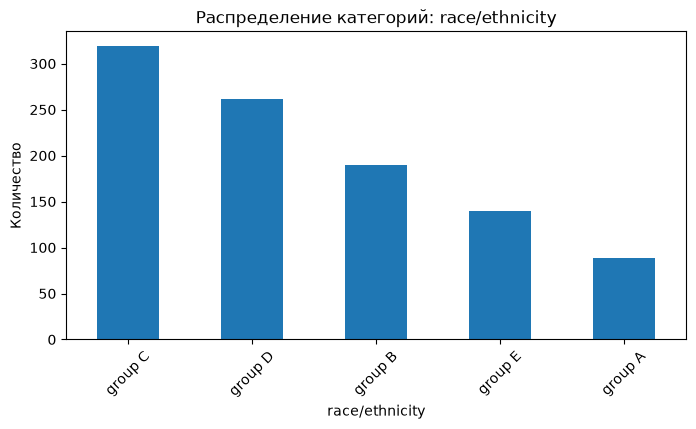

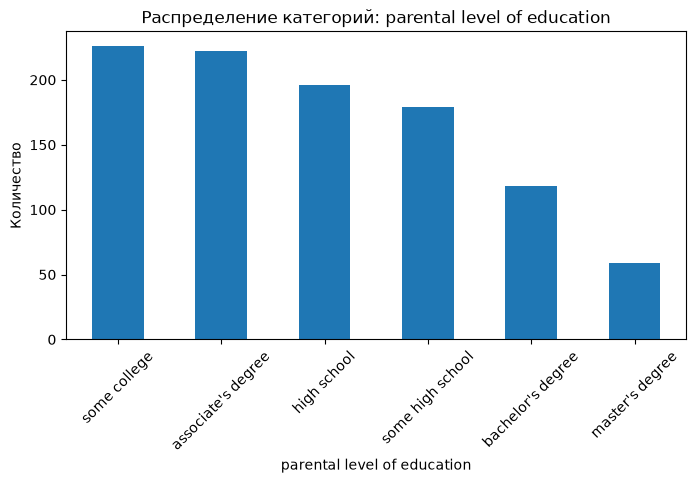

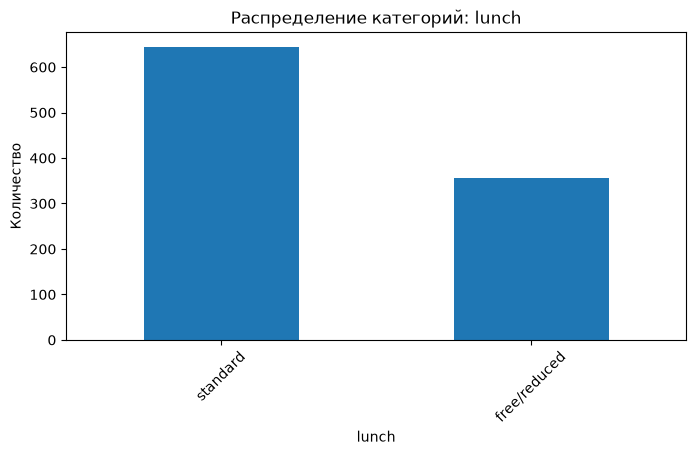

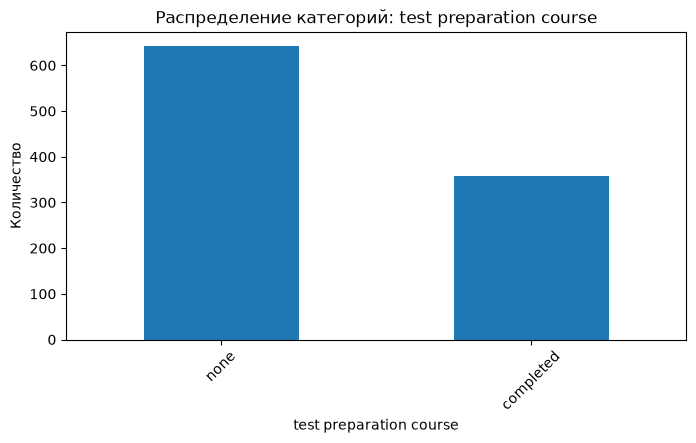

In [16]:
for col in categorical_cols:
    plt.figure(figsize=(8, 4))
    
    df[col].value_counts().plot(kind="bar")
    
    plt.title(f"Распределение категорий: {col}")
    plt.xlabel(col)
    plt.ylabel("Количество")
    plt.xticks(rotation=45)
    plt.show()

In [17]:
corr = df[numeric_cols].corr()

corr

,math score,reading score,writing score
math score,1.000000,0.817580,0.802642
reading score,0.817580,1.000000,0.954598
writing score,0.802642,0.954598,1.000000


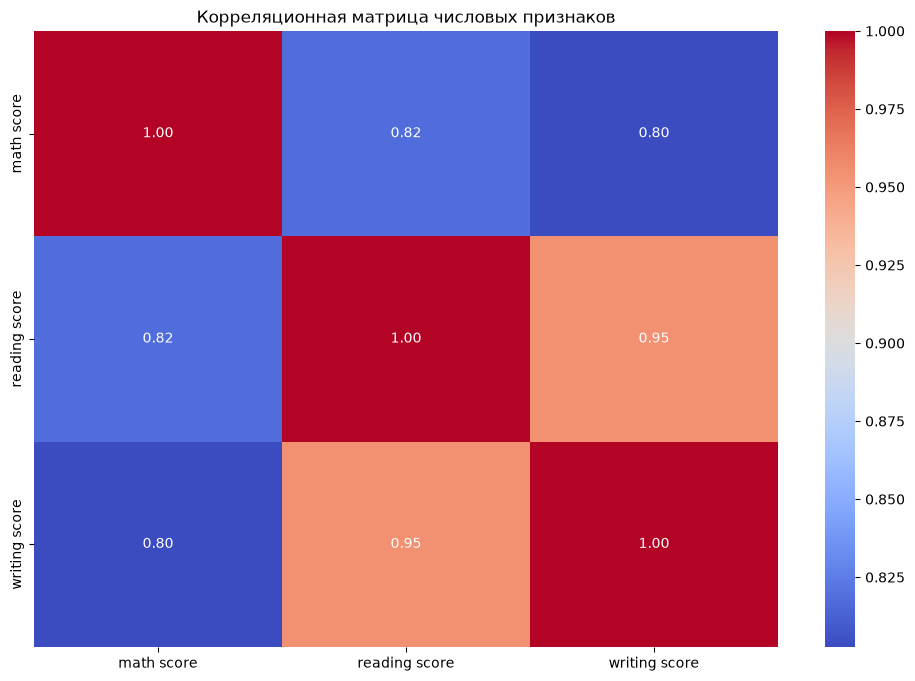

In [18]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Корреляционная матрица числовых признаков")
plt.show()

In [19]:
corr_pairs = corr.where(
    np.triu(np.ones(corr.shape), k=1).astype(bool)
)

corr_pairs = corr_pairs.stack().sort_values(
    key=abs,
    ascending=False
)

corr_pairs.head(10)

reading score  writing score    0.954598
math score     reading score    0.817580
               writing score    0.802642
               math score            NaN
reading score  math score            NaN
               reading score         NaN
writing score  math score            NaN
               reading score         NaN
               writing score         NaN
dtype: float64

In [21]:
print(df.columns.tolist())

['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course', 'math score', 'reading score', 'writing score']


In [22]:
corr = df[numeric_cols].corr()

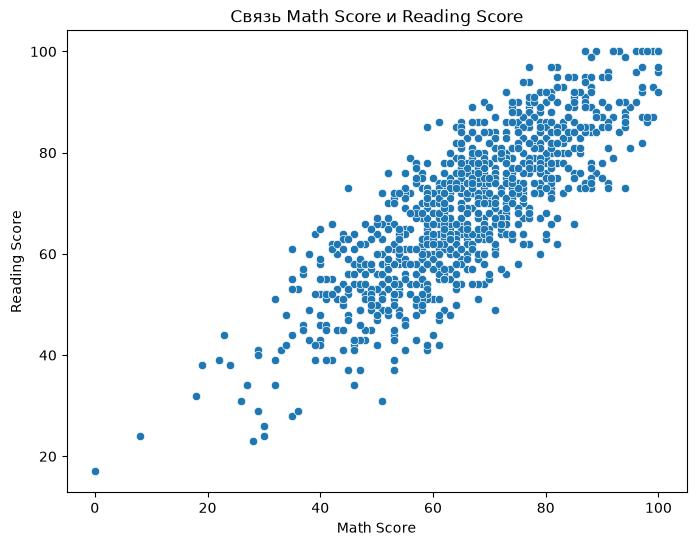

In [27]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x="math score",
    y="reading score"
)

plt.title("Связь Math Score и Reading Score")
plt.xlabel("Math Score")
plt.ylabel("Reading Score")
plt.show()

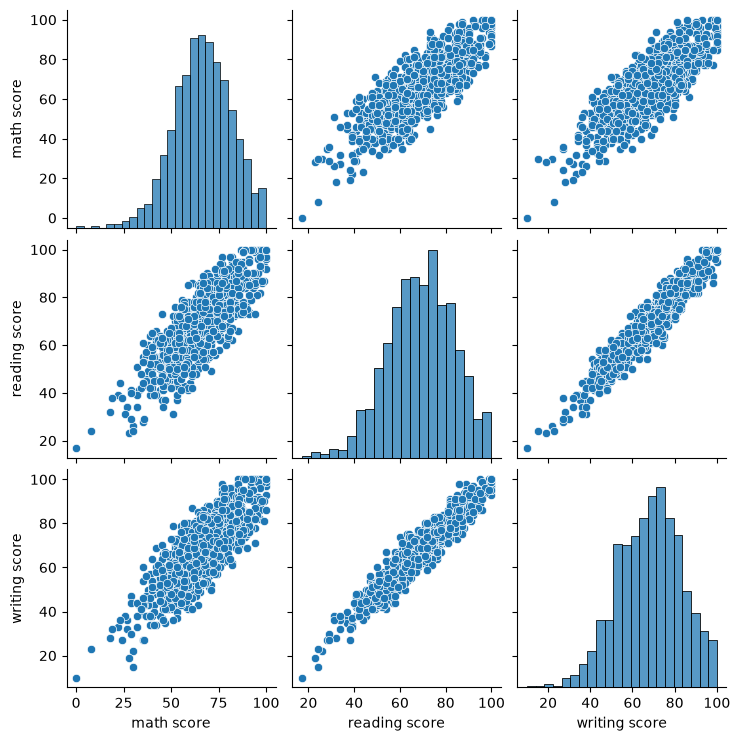

In [28]:
top_features = ["math score", "reading score", "writing score", "parental level of education"]

sns.pairplot(
    df[top_features].dropna()
)

plt.show()

In [32]:
df["average_score"] = df[
    ["math score", "reading score", "writing score"]
].mean(axis=1)

In [33]:
df["label"] = (df["average_score"] >= 60).astype(int)

label
1    715
0    285
Name: count, dtype: int64
label
1    71.5
0    28.5
Name: proportion, dtype: float64


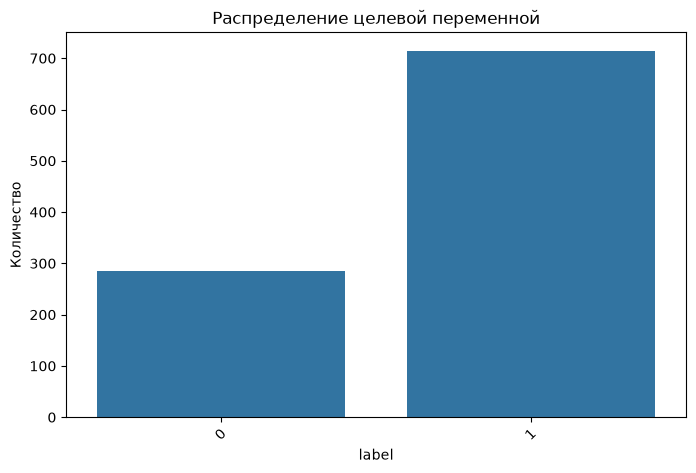

In [34]:
target = "label"

print(df[target].value_counts())

print(df[target].value_counts(normalize=True) * 100)

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x=target
)

plt.title("Распределение целевой переменной")
plt.xlabel(target)
plt.ylabel("Количество")
plt.xticks(rotation=45)

plt.show()